In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import alpha

In [24]:
titanic = sns.load_dataset('titanic')

# Missing Value

In [47]:
missing_value = titanic.isna().sum()
missing_value = missing_value[missing_value > 0]
print(missing_value)
titanic.shape

age            177
embarked         2
deck           688
embark_town      2
dtype: int64


(891, 15)

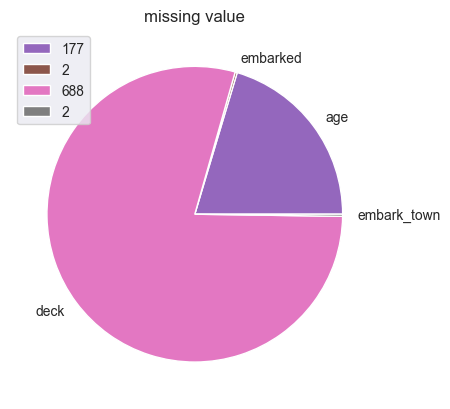

In [42]:
plt.pie(missing_value, labels=missing_value.index)
plt.title('missing value')
circle, text = plt.pie(missing_value)
plt.legend(circle, missing_value)
plt.show()

# Wrong Format

In [106]:
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [51]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [56]:
for col in titanic.columns:
    print(titanic[col].value_counts())

survived
0    549
1    342
Name: count, dtype: int64
pclass
3    491
1    216
2    184
Name: count, dtype: int64
sex
male      577
female    314
Name: count, dtype: int64
age
24.00    30
22.00    27
18.00    26
28.00    25
19.00    25
         ..
24.50     1
0.67      1
0.42      1
34.50     1
74.00     1
Name: count, Length: 88, dtype: int64
sibsp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64
parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64
fare
8.0500     43
13.0000    42
7.8958     38
7.7500     34
26.0000    31
           ..
13.8583     1
50.4958     1
5.0000      1
9.8458      1
10.5167     1
Name: count, Length: 248, dtype: int64
embarked
S    644
C    168
Q     77
Name: count, dtype: int64
class
Third     491
First     216
Second    184
Name: count, dtype: int64
who
man      537
woman    271
child     83
Name: count, dtype: int64
adult_male
True     537
False    354
Name: count, dtype: int64

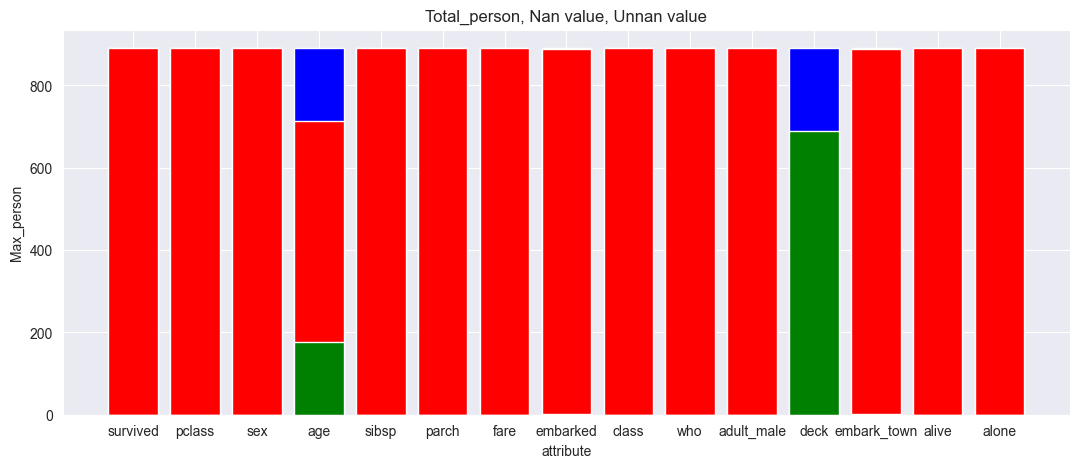

In [105]:
plt.figure(figsize=(13,5))
for col in titanic.columns:
    missing = titanic[col].isna().sum()
    exist = titanic[col].notna().sum()
    max1 = missing + exist
    plt.bar(col,max1, color='blue')
    plt.bar(col,exist, color='red')
    plt.bar(col,missing, color='green')

plt.xlabel("attribute")
plt.ylabel("Max_person")
plt.title('Total_person, Nan value, Unnan value')
plt.show()

# Out of range

In [110]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [109]:
for col in titanic.columns:
    print(titanic[col].value_counts())

survived
0    549
1    342
Name: count, dtype: int64
pclass
3    491
1    216
2    184
Name: count, dtype: int64
sex
male      577
female    314
Name: count, dtype: int64
age
24.00    30
22.00    27
18.00    26
28.00    25
19.00    25
         ..
24.50     1
0.67      1
0.42      1
34.50     1
74.00     1
Name: count, Length: 88, dtype: int64
sibsp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64
parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64
fare
8.0500     43
13.0000    42
7.8958     38
7.7500     34
26.0000    31
           ..
13.8583     1
50.4958     1
5.0000      1
9.8458      1
10.5167     1
Name: count, Length: 248, dtype: int64
embarked
S    644
C    168
Q     77
Name: count, dtype: int64
class
Third     491
First     216
Second    184
Name: count, dtype: int64
who
man      537
woman    271
child     83
Name: count, dtype: int64
adult_male
True     537
False    354
Name: count, dtype: int64

In [111]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


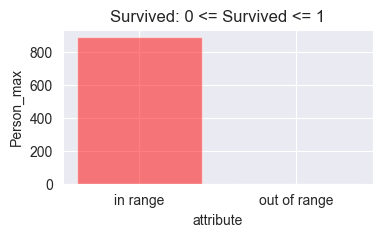

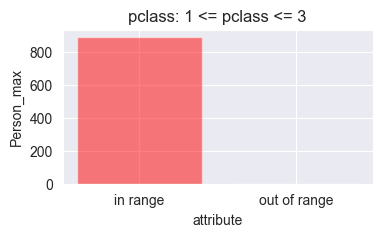

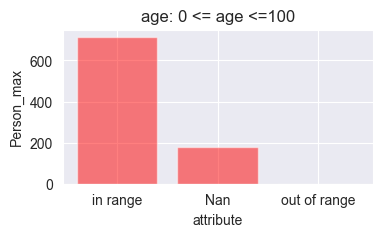

In [176]:
in_range = titanic.loc[(titanic['survived'] >= 0) & (titanic['survived'] <= 1), 'survived'].shape[0]
out_of_range = titanic.loc[(titanic['survived'] < 0) & (titanic['survived'] > 1), 'survived'].shape[0]
plt.figure(figsize=(4,2))
plt.bar('in range', in_range, color='red', alpha=0.5)
plt.bar('out of range', out_of_range, color='blue', alpha=0.5)
plt.title('Survived: 0 <= Survived <= 1')
plt.xlabel('attribute')
plt.ylabel('Person_max')
plt.show()

in_range = titanic.loc[(titanic['pclass'] >= 1) & (titanic['pclass'] <= 3), 'pclass'].shape[0]
out_of_range = titanic.loc[(titanic['survived'] < 1) & (titanic['pclass'] > 3), 'pclass'].shape[0]
plt.figure(figsize=(4,2))
plt.bar('in range', in_range, color='red', alpha=0.5)
plt.bar('out of range', out_of_range, color='blue', alpha=0.5)
plt.xlabel('attribute')
plt.ylabel('Person_max')
plt.title('pclass: 1 <= pclass <= 3')
plt.show()

in_range = titanic.loc[(titanic['age'] >= 0) & (titanic['age'] <= 100), 'age'].shape[0]
out_of_range = titanic.loc[(titanic['age'] < 0) & (titanic['age'] > 100), 'age'].shape[0]
nan_max = titanic['age'].isna().sum()
plt.figure(figsize=(4,2))
plt.bar('in range', in_range, color='red', alpha=0.5)
plt.bar('Nan', nan_max, color='red', alpha=0.5)
plt.bar('out of range', out_of_range, color='blue', alpha=0.5)
plt.title('age: 0 <= age <=100')
plt.xlabel('attribute')
plt.ylabel('Person_max')
plt.show()



# Outlier

In [163]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


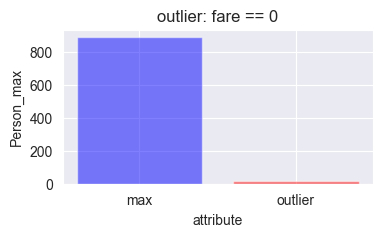

In [175]:
out_value = titanic.loc[titanic['fare'] == 0, 'fare'].shape[0]
max1 = titanic['fare'].count()

plt.figure(figsize=(4,2))
plt.bar('max', max1, color='blue', alpha=0.5)
plt.bar('outlier', out_value, color='red', alpha=0.5)
plt.title('outlier: fare == 0')
plt.xlabel('attribute')
plt.ylabel('Person_max')
plt.show()